In [1]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [2]:
# Load the IMDB dataset
from tensorflow.keras.datasets import imdb

# Only keep the top 10,000 most frequent words
num_words = 10000
(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=num_words)

print(f"Training Data Shape: {X_train.shape}")
print(f"Testing Data Shape: {X_test.shape}")

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step
Training Data Shape: (25000,)
Testing Data Shape: (25000,)


In [3]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Pad sequences so that all have the same length
maxlen = 200  # maximum review length

X_train_padded = pad_sequences(X_train, maxlen=maxlen)
X_test_padded = pad_sequences(X_test, maxlen=maxlen)

In [4]:
# Build the model
model = keras.Sequential([
    layers.Embedding(input_dim=num_words, output_dim=32, input_length=maxlen),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(1, activation='sigmoid')  # Sigmoid activation for binary classification
])

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

d:\collegePrograms\sem8\prac\myenv\Lib\site-packages\keras\src\layers\core\embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [5]:
# Train the model
history = model.fit(X_train_padded, y_train, epochs=10, batch_size=32, validation_split=0.2, verbose=1)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 15s 18ms/step - accuracy: 0.6713 - loss: 0.5505 - val_accuracy: 0.8586 - val_loss: 0.3301
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 12s 19ms/step - accuracy: 0.9564 - loss: 0.1294 - val_accuracy: 0.8446 - val_loss: 0.4101
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - accuracy: 0.9940 - loss: 0.0237 - val_accuracy: 0.8450 - val_loss: 0.5290
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 17ms/step - accuracy: 0.9994 - loss: 0.0037 - val_accuracy: 0.8394 - val_loss: 0.6463
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.9992 - loss: 0.0028 - val_accuracy: 0.8462 - val_loss: 0.6477
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 13s 20ms/step - accuracy: 1.0000 - loss: 3.0625e-04 - val_accuracy: 0.8476 - val_loss: 0.6743
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 1.0000 - loss: 1.2650e-04 - val_accuracy: 0.8500 - val_loss: 0.6920
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - accuracy: 1.0000 - loss: 7

In [6]:
# Evaluate on the test set
test_loss, test_accuracy = model.evaluate(X_test_padded, y_test, verbose=2)

print(f"Test Loss: {test_loss:.2f}")
print(f"Test Accuracy: {test_accuracy:.2f}")


782/782 - 3s - 4ms/step - accuracy: 0.8475 - loss: 0.7549
Test Loss: 0.75
Test Accuracy: 0.85


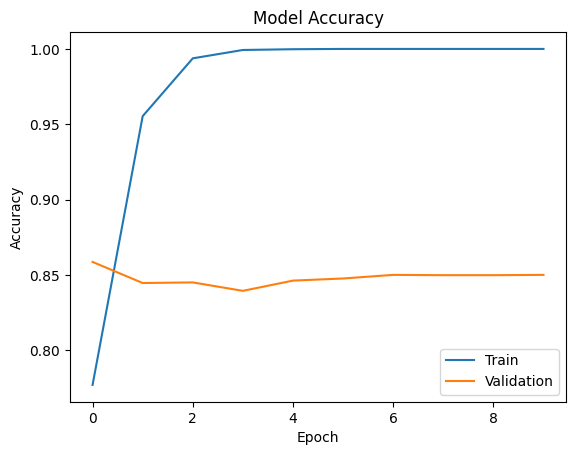

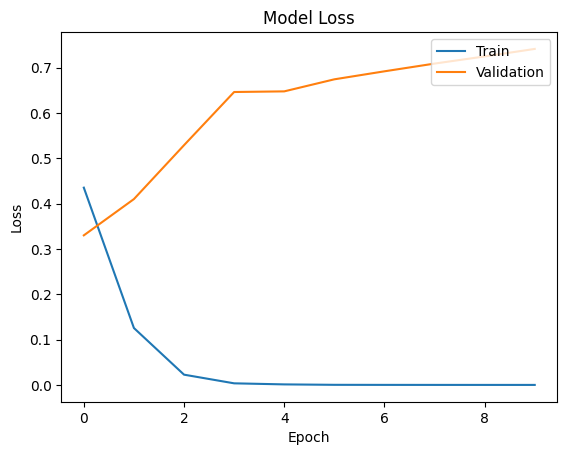

In [7]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='lower right')
plt.show()

# Plot training & validation loss values
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper right')
plt.show()

In [8]:
# Predict first 5 reviews
predictions = model.predict(X_test_padded[:5])

# Display predictions
for i, pred in enumerate(predictions):
    print(f"Review {i+1}: Predicted Sentiment: {'Positive' if pred[0] > 0.5 else 'Negative'} | Actual Sentiment: {'Positive' if y_test[i]==1 else 'Negative'}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 315ms/step
Review 1: Predicted Sentiment: Negative | Actual Sentiment: Negative
Review 2: Predicted Sentiment: Positive | Actual Sentiment: Positive
Review 3: Predicted Sentiment: Positive | Actual Sentiment: Positive
Review 4: Predicted Sentiment: Negative | Actual Sentiment: Negative
Review 5: Predicted Sentiment: Positive | Actual Sentiment: Positive


1. What is the purpose of this code?
Answer:
The code builds and trains a deep neural network to predict the sentiment (positive or negative) of movie reviews from the IMDB dataset.

2. Which dataset are you using? How do you load it?
Answer:
I'm using the IMDB movie review dataset, loaded from tensorflow.keras.datasets.imdb.

3. Why do you set num_words=10000 while loading the dataset?
Answer:
To keep only the top 10,000 most frequent words and ignore rare words, which simplifies the model and speeds up training.

4. Why do you pad the sequences?
Answer:
Because reviews are of different lengths,
padding ensures all input sequences have the same fixed length, required by neural networks.

5. What does pad_sequences do?
Answer:
It pads shorter sequences with zeros so that every review has the same number of words (here, 200 words).

6. What does the Embedding layer do?
Answer:
It converts word indices into dense 32-dimensional vectors, which capture the meaning of words better for the model.

7. Why use Flatten after the Embedding layer?
Answer:
Flattening converts the 2D embedding output into 1D, so that it can be fed into the dense layers.

8. What does the final output layer do?
Answer:
It has 1 neuron with sigmoid activation, outputting a probability between 0 and 1 for binary classification (positive/negative sentiment).

9. Which optimizer and loss function are you using?
Answer:
Optimizer: Adam,
Loss function: Binary Crossentropy, because it's a binary classification problem.

10. What metrics are you monitoring?
Answer:
I am monitoring Accuracy during training and evaluation.

11. How many epochs are you training for?
Answer:
I am training for 10 epochs.

12. What does validation_split=0.2 mean?
Answer:
It uses 20% of the training data for validation to monitor the model’s generalization during training.

13. Why plot accuracy and loss graphs?
Answer:
To visualize how the model is learning over epochs, and to detect overfitting or underfitting.

14. What are you predicting at the end?
Answer:
I'm predicting the sentiment for the first 5 test reviews and comparing predicted and actual sentiments.

15. How do you interpret the model's prediction output?
Answer:
If the output probability > 0.5, the sentiment is Positive; otherwise, it's Negative.

16. Why use sigmoid activation for binary classification?
Answer:
Because sigmoid maps the output between 0 and 1, representing probabilities suitable for binary decisions.

17. What are the shapes of your input data after padding?
Answer:
Each review becomes a vector of length 200 after padding.